In [1]:
import pandas as pd

In [2]:
data = pd.read_excel("iris_dataset.xlsx")
data

,SepalLengthC,SepalWidthC,PetalLengthC,PetalWidthC,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
from sklearn.model_selection import train_test_split

data_train,data_test = train_test_split(data,test_size=0.25)

data_test.to_excel("test.xlsx",index=False)
data_train.to_excel("train.xlsx",index=False)

In [4]:
d_train_setosa = pd.read_excel("train.xlsx")
d_train_setosa = d_train_setosa[d_train_setosa["Species"]=="setosa"]
del d_train_setosa["Species"]
d_train_setosa.to_csv("train_setosa.csv",index=False)

In [5]:
d_train_versicolor = pd.read_excel("train.xlsx")
d_train_versicolor = d_train_versicolor[d_train_versicolor["Species"]=="versicolor"]
del d_train_versicolor["Species"]
d_train_versicolor.to_csv("train_versicolor.csv",index=False)

In [6]:
d_train_virginica = pd.read_excel("train.xlsx")
d_train_virginica = d_train_virginica[d_train_virginica["Species"]=="virginica"]
del d_train_virginica["Species"]
d_train_virginica.to_csv("train_virginica.csv",index=False)

In [7]:
from mlforkidsnumbers import MLforKidsNumbers

project = MLforKidsNumbers(
    modelurl="https://mlforkids-newnumbers.j8clybxvjr0.us-south.codeengine.appdomain.cloud/saved-models/auth0|6a48f620676b6631a8f2a91f-1/status"
)



 MLforKids : Checking for downloaded model... 
 MLforKids : Reusing downloaded model from saved_models\auth0_6a48f620676b6631a8f2a91f-1 
 MLforKids : Loading model... 
 MLforKids : Accessing model metadata... 
 MLforKids : Model trained at 2026-09-21T07:30:39.451887 


In [8]:
testvalue = {
    "SepalLengthC" : 0,
    "SepalWidthC" : 0,
    "PetalLengthC" : 0,
    "PetalWidthC" : 0,
}
data_test

,SepalLengthC,SepalWidthC,PetalLengthC,PetalWidthC,Species
60,5.0,2.0,3.5,1.0,versicolor
48,5.3,3.7,1.5,0.2,setosa
149,5.9,3.0,5.1,1.8,virginica
34,4.9,3.1,1.5,0.2,setosa
142,5.8,2.7,5.1,1.9,virginica
93,5.0,2.3,3.3,1.0,versicolor
5,5.4,3.9,1.7,0.4,setosa
135,7.7,3.0,6.1,2.3,virginica
107,7.3,2.9,6.3,1.8,virginica
11,4.8,3.4,1.6,0.2,setosa


In [9]:
data_test=pd.read_excel("test.xlsx")
data_test

,SepalLengthC,SepalWidthC,PetalLengthC,PetalWidthC,Species
0,5.0,2.0,3.5,1.0,versicolor
1,5.3,3.7,1.5,0.2,setosa
2,5.9,3.0,5.1,1.8,virginica
3,4.9,3.1,1.5,0.2,setosa
4,5.8,2.7,5.1,1.9,virginica
5,5.0,2.3,3.3,1.0,versicolor
6,5.4,3.9,1.7,0.4,setosa
7,7.7,3.0,6.1,2.3,virginica
8,7.3,2.9,6.3,1.8,virginica
9,4.8,3.4,1.6,0.2,setosa


In [10]:
p=[]

for i in range(38):
    prediction2 = project.classify({
        "SepalLengthC" : data_test.iloc[i]["SepalLengthC"],
        "SepalWidthC" : data_test.iloc[i]["SepalWidthC"],
        "PetalLengthC" : data_test.iloc[i]["PetalLengthC"],
        "PetalWidthC" : data_test.iloc[i]["PetalWidthC"], 
    })
    p.append(prediction2[0]["class_name"])
    

In [11]:
data_test=pd.read_excel("test.xlsx")
data_test["prediction"]=p
data_test.to_excel("test.xlsx",index=False)

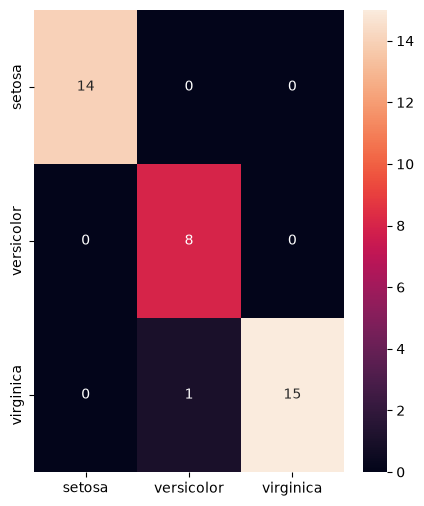

In [12]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import  matplotlib.pyplot  as plt 

data_test=pd.read_excel('test.xlsx')

truth=data_test["Species"].values
predictions=data_test["prediction"].values

cm=confusion_matrix(predictions,truth,labels=["setosa","versicolor","virginica"])

plt.figure(figsize=(5,6))
sns.heatmap(cm,annot=True,xticklabels=["setosa","versicolor","virginica"],yticklabels=["setosa","versicolor","virginica"])

plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(truth,predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.89      0.94         9
   virginica       0.94      1.00      0.97        15

    accuracy                           0.97        38
   macro avg       0.98      0.96      0.97        38
weighted avg       0.98      0.97      0.97        38

